# OrbitalWatch AI

O **OrbitalWatch AI** usa dados da **NASA FIRMS** para classificar focos de calor detectados por satélite em níveis de risco. A ideia é apoiar o monitoramento ambiental, ajudando a priorizar ocorrências mais relevantes dentro da plataforma OrbitalWatch.

A ideia é classificar cada foco de calor em:

- `baixo`
- `medio`
- `alto`

Assim, em uma plataforma como o OrbitalWatch, os focos mais críticos poderiam aparecer primeiro no dashboard ou gerar alertas com maior prioridade.

## 1. Bibliotecas

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

pd.set_option("display.max_columns", 100)

## 2. Carregamento dos arquivos

Foram usados três arquivos da NASA FIRMS:

- `fire_nrt_J1V-C2.csv`: focos de calor do sensor VIIRS no satélite NOAA-20/JPSS-1.
- `fire_nrt_SV-C2.csv`: focos de calor do sensor VIIRS no satélite Suomi NPP.
- `fire_nrt_M-C61.csv`: focos de calor do sensor MODIS, usado como complemento.

Os arquivos devem ficar na mesma pasta deste notebook.

In [37]:
arquivos = [
    "datasets/fire_nrt_J1V-C2.csv",
    "datasets/fire_nrt_SV-C2.csv",
    "datasets/fire_nrt_M-C61.csv"
]

USAR_AMOSTRA = True
LINHAS_POR_ARQUIVO = 100_000

bases = []

for arquivo in arquivos:
    if USAR_AMOSTRA:
        dados = pd.read_csv(arquivo, nrows=LINHAS_POR_ARQUIVO)
    else:
        dados = pd.read_csv(arquivo)

    dados["arquivo_origem"] = arquivo
    bases.append(dados)

df = pd.concat(bases, ignore_index=True)

print("Linhas e colunas:", df.shape)
df.head()

Linhas e colunas: (300000, 15)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,arquivo_origem
0,70.39933,68.27425,323.29,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,258.44,3.14,N,datasets/fire_nrt_J1V-C2.csv
1,70.39788,68.27815,338.50,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,260.52,3.08,N,datasets/fire_nrt_J1V-C2.csv
2,70.38014,68.29300,320.24,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,254.21,1.92,N,datasets/fire_nrt_J1V-C2.csv
3,65.77070,24.18973,323.35,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,266.97,1.64,N,datasets/fire_nrt_J1V-C2.csv
4,65.76741,24.18719,338.44,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,269.87,5.80,N,datasets/fire_nrt_J1V-C2.csv


## 3. Primeira olhada nos dados

Aqui é só para conferir se os arquivos foram carregados corretamente e ver quais colunas vieram na base.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   latitude        300000 non-null  float64
 1   longitude       300000 non-null  float64
 2   brightness      300000 non-null  float64
 3   scan            300000 non-null  float64
 4   track           300000 non-null  float64
 5   acq_date        300000 non-null  object 
 6   acq_time        300000 non-null  int64  
 7   satellite       300000 non-null  object 
 8   instrument      300000 non-null  object 
 9   confidence      300000 non-null  object 
 10  version         300000 non-null  object 
 11  bright_t31      300000 non-null  float64
 12  frp             300000 non-null  float64
 13  daynight        300000 non-null  object 
 14  arquivo_origem  300000 non-null  object 
dtypes: float64(7), int64(1), object(7)
memory usage: 34.3+ MB


In [39]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,arquivo_origem
0,70.39933,68.27425,323.29,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,258.44,3.14,N,datasets/fire_nrt_J1V-C2.csv
1,70.39788,68.27815,338.50,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,260.52,3.08,N,datasets/fire_nrt_J1V-C2.csv
2,70.38014,68.29300,320.24,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,254.21,1.92,N,datasets/fire_nrt_J1V-C2.csv
3,65.77070,24.18973,323.35,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,266.97,1.64,N,datasets/fire_nrt_J1V-C2.csv
4,65.76741,24.18719,338.44,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,269.87,5.80,N,datasets/fire_nrt_J1V-C2.csv


## Leitura inicial da base

A base carregada ficou com **300.000 registros e 15 colunas**, usando amostra de 100.000 linhas de cada arquivo. Isso é suficiente para testar o pipeline sem deixar o notebook pesado.

Os dados representam focos de calor detectados por satélite. As colunas principais indicam a localização do foco (`latitude` e `longitude`), a intensidade térmica detectada (`brightness`/`temperatura_brilho_principal`), a potência radiativa do fogo (`frp`), o satélite, o sensor utilizado, a confiança da detecção e se o registro ocorreu de dia ou de noite.

Nesta etapa, o objetivo foi confirmar que os três arquivos foram carregados corretamente e que as colunas necessárias para o modelo estavam disponíveis.

## 4. Ajuste dos nomes das colunas

Os arquivos VIIRS e MODIS usam nomes um pouco diferentes para algumas medidas térmicas.  
Para facilitar o restante do notebook, foram criados nomes mais fáceis de entender.

- `temperatura_brilho_principal`: medida principal de brilho/temperatura do foco.
- `temperatura_brilho_secundaria`: segunda medida térmica disponível.

In [40]:
df.columns = [
    coluna.strip().lower().replace(" ", "_").replace("-", "_")
    for coluna in df.columns
]

df = df.rename(columns={
    "brightness": "temperatura_brilho_principal",
    "bright_ti4": "temperatura_brilho_principal",
    "bright_t31": "temperatura_brilho_secundaria",
    "bright_ti5": "temperatura_brilho_secundaria"
})

df.head()

,latitude,longitude,temperatura_brilho_principal,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,temperatura_brilho_secundaria,frp,daynight,arquivo_origem
0,70.39933,68.27425,323.29,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,258.44,3.14,N,datasets/fire_nrt_J1V-C2.csv
1,70.39788,68.27815,338.50,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,260.52,3.08,N,datasets/fire_nrt_J1V-C2.csv
2,70.38014,68.29300,320.24,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,254.21,1.92,N,datasets/fire_nrt_J1V-C2.csv
3,65.77070,24.18973,323.35,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,266.97,1.64,N,datasets/fire_nrt_J1V-C2.csv
4,65.76741,24.18719,338.44,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,269.87,5.80,N,datasets/fire_nrt_J1V-C2.csv


## 5. Preparação das variáveis

Algumas colunas vêm como texto. Para treinar os modelos, elas foram transformadas em números:

- `confianca_deteccao`: confiança do foco detectado pelo satélite.
- `periodo_dia_noite`: se a detecção foi feita de dia ou à noite.
- `codigo_instrumento`: código numérico do sensor.
- `codigo_satelite`: código numérico do satélite.

In [41]:
df_proc = df.copy()

if df_proc["confidence"].dtype == "object":
    mapa_confianca = {
        "l": 0,
        "low": 0,
        "n": 1,
        "nominal": 1,
        "h": 2,
        "high": 2
    }

    df_proc["confianca_deteccao"] = (
        df_proc["confidence"]
        .astype(str)
        .str.lower()
        .map(mapa_confianca)
    )
else:
    confianca = pd.to_numeric(df_proc["confidence"], errors="coerce")

    df_proc["confianca_deteccao"] = pd.cut(
        confianca,
        bins=[-1, 30, 70, 100],
        labels=[0, 1, 2]
    ).astype(float)

df_proc["periodo_dia_noite"] = (
    df_proc["daynight"]
    .astype(str)
    .str.upper()
    .map({"D": 0, "N": 1})
)

df_proc["codigo_instrumento"] = df_proc["instrument"].astype("category").cat.codes
df_proc["codigo_satelite"] = df_proc["satellite"].astype("category").cat.codes

colunas_numericas = [
    "latitude",
    "longitude",
    "temperatura_brilho_principal",
    "temperatura_brilho_secundaria",
    "scan",
    "track",
    "frp",
    "confianca_deteccao",
    "periodo_dia_noite",
    "codigo_instrumento",
    "codigo_satelite"
]

for coluna in colunas_numericas:
    df_proc[coluna] = pd.to_numeric(df_proc[coluna], errors="coerce")

df_proc[colunas_numericas].head()

,latitude,longitude,temperatura_brilho_principal,temperatura_brilho_secundaria,scan,track,frp,confianca_deteccao,periodo_dia_noite,codigo_instrumento,codigo_satelite
0,70.39933,68.27425,323.29,258.44,0.32,0.55,3.14,1.0,1,1,2
1,70.39788,68.27815,338.50,260.52,0.32,0.55,3.08,1.0,1,1,2
2,70.38014,68.29300,320.24,254.21,0.32,0.55,1.92,1.0,1,1,2
3,65.77070,24.18973,323.35,266.97,0.41,0.37,1.64,1.0,1,1,2
4,65.76741,24.18719,338.44,269.87,0.41,0.37,5.80,1.0,1,1,2


## 6. O que o modelo vai prever

A base da NASA FIRMS informa que um foco de calor foi detectado, mas não traz uma coluna pronta dizendo a prioridade desse foco.

Por isso, foi criada a variável `risco`. Ela representa uma prioridade inicial para o OrbitalWatch:

- `baixo`: foco menos intenso;
- `medio`: foco intermediário;
- `alto`: foco mais relevante para alerta.

Essa classificação usa principalmente:

- `frp`, que indica a potência radiativa do fogo;
- `temperatura_brilho_principal`, que indica a intensidade térmica;
- `confianca_deteccao`, que indica a confiança da detecção.

In [42]:
base_risco = (
    df_proc["frp"].fillna(df_proc["frp"].median()) * 0.55
    + df_proc["temperatura_brilho_principal"].fillna(df_proc["temperatura_brilho_principal"].median()) * 0.35
    + df_proc["confianca_deteccao"].fillna(df_proc["confianca_deteccao"].median()) * 10
)

df_proc["risco"] = pd.qcut(
    base_risco.rank(method="first"),
    q=3,
    labels=["baixo", "medio", "alto"]
)

df_proc["risco"].value_counts()

risco
baixo    100000
medio    100000
alto     100000
Name: count, dtype: int64

## Interpretação da variável `risco`

A variável `risco` foi criada porque a base da NASA FIRMS informa os focos de calor, mas não entrega uma classificação pronta de prioridade.

A classificação foi construída a partir de variáveis que fazem sentido para o problema:

- `frp`: indica a potência radiativa do fogo;
- `temperatura_brilho_principal`: representa a intensidade térmica observada pelo satélite;
- `confianca_deteccao`: indica o nível de confiança da detecção.

A divisão em `baixo`, `medio` e `alto` cria uma forma simples de priorizar os registros. Isso transforma os dados brutos de satélite em uma tarefa de classificação para o OrbitalWatch.

## 7. Dataset final

Aqui ficam as variáveis usadas pelo modelo e a coluna `risco`, que será a variável prevista.

In [43]:
features = [
    "latitude",
    "longitude",
    "temperatura_brilho_principal",
    "temperatura_brilho_secundaria",
    "scan",
    "track",
    "frp",
    "confianca_deteccao",
    "periodo_dia_noite",
    "codigo_instrumento",
    "codigo_satelite"
]

dataset = df_proc[features + ["risco"]].copy()
dataset = dataset.dropna(subset=["risco"])

print("Dimensão final:", dataset.shape)
dataset.head()

Dimensão final: (300000, 12)


,latitude,longitude,temperatura_brilho_principal,temperatura_brilho_secundaria,scan,track,frp,confianca_deteccao,periodo_dia_noite,codigo_instrumento,codigo_satelite,risco
0,70.39933,68.27425,323.29,258.44,0.32,0.55,3.14,1.0,1,1,2,baixo
1,70.39788,68.27815,338.50,260.52,0.32,0.55,3.08,1.0,1,1,2,medio
2,70.38014,68.29300,320.24,254.21,0.32,0.55,1.92,1.0,1,1,2,baixo
3,65.77070,24.18973,323.35,266.97,0.41,0.37,1.64,1.0,1,1,2,baixo
4,65.76741,24.18719,338.44,269.87,0.41,0.37,5.80,1.0,1,1,2,medio


## 8. Divisão entre treino e teste

A base foi dividida em treino e teste.  
O treino ensina o modelo, e o teste verifica como ele se comporta em dados que não foram usados no treinamento.

In [44]:
X = dataset[features]
y = dataset["risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (225000, 11)
Teste: (75000, 11)


## 9. Treinamento dos modelos

Foram comparados dois modelos:

- **Regressão Logística**, como modelo mais simples;
- **Random Forest**, como modelo mais robusto para relações não lineares.

A comparação mostra qual dos dois funciona melhor para essa classificação de risco.

In [45]:
modelos = {
    "Regressao_Logistica": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random_Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=8,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, previsoes)
    f1 = f1_score(y_test, previsoes, average="weighted")

    resultados.append({
        "modelo": nome,
        "accuracy": accuracy,
        "f1_weighted": f1
    })

    print("\n" + "=" * 70)
    print(nome)
    print("=" * 70)
    print(classification_report(y_test, previsoes))

resultados_df = pd.DataFrame(resultados).sort_values("f1_weighted", ascending=False)
resultados_df


Regressao_Logistica
              precision    recall  f1-score   support

        alto       1.00      0.99      1.00     25000
       baixo       1.00      0.99      0.99     25000
       medio       0.98      0.99      0.99     25000

    accuracy                           0.99     75000
   macro avg       0.99      0.99      0.99     75000
weighted avg       0.99      0.99      0.99     75000


Random_Forest
              precision    recall  f1-score   support

        alto       0.99      0.97      0.98     25000
       baixo       0.99      0.96      0.97     25000
       medio       0.93      0.98      0.95     25000

    accuracy                           0.97     75000
   macro avg       0.97      0.97      0.97     75000
weighted avg       0.97      0.97      0.97     75000



,modelo,accuracy,f1_weighted
0,Regressao_Logistica,0.99272,0.992730
1,Random_Forest,0.96852,0.968721


## Análise dos modelos

Foram comparados dois modelos: Regressão Logística e Random Forest.

No resultado obtido, a **Regressão Logística teve o melhor desempenho**, com acurácia aproximada de **99,27%** e F1-score ponderado de **99,27%**. O Random Forest também teve desempenho alto, com acurácia aproximada de **96,85%**.

Esse resultado indica que a separação entre os níveis de risco ficou bem definida pelas variáveis usadas na regra de criação do alvo, principalmente `frp`, temperatura de brilho e confiança da detecção. Por isso, mesmo um modelo mais simples conseguiu separar bem as classes.

## 10. Comparação dos modelos

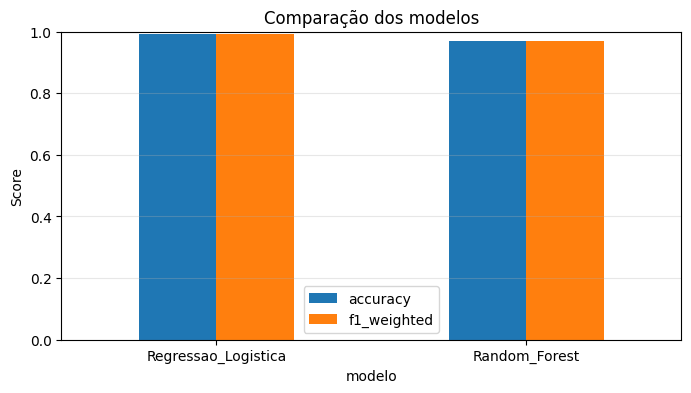

In [46]:
resultados_df.plot(
    x="modelo",
    y=["accuracy", "f1_weighted"],
    kind="bar",
    figsize=(8, 4)
)

plt.title("Comparação dos modelos")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 11. Matriz de confusão

A matriz mostra onde o melhor modelo acertou e onde confundiu as classes `baixo`, `medio` e `alto`.

Melhor modelo: Regressao_Logistica


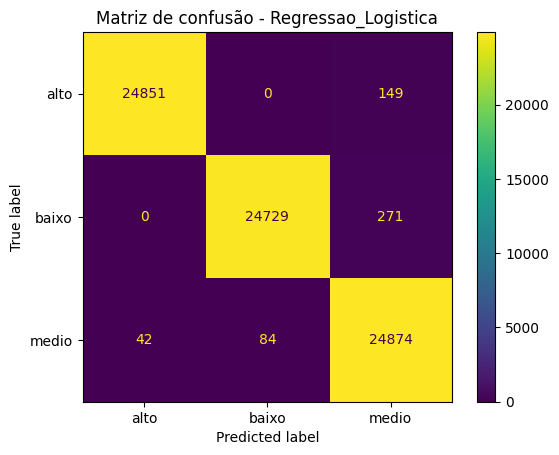

In [47]:
melhor_nome = resultados_df.iloc[0]["modelo"]
melhor_modelo = modelos[melhor_nome]

print("Melhor modelo:", melhor_nome)

previsoes_melhor = melhor_modelo.predict(X_test)

cm = confusion_matrix(
    y_test,
    previsoes_melhor,
    labels=melhor_modelo.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=melhor_modelo.classes_
)

disp.plot()
plt.title(f"Matriz de confusão - {melhor_nome}")
plt.show()

## Leitura da matriz de confusão

A matriz de confusão mostra que o melhor modelo conseguiu classificar bem as três categorias de risco.

Os erros aparecem principalmente em registros próximos das fronteiras entre `baixo`, `medio` e `alto`, o que é esperado nesse tipo de classificação. Como a variável de risco foi criada por faixas, alguns casos ficam naturalmente perto do limite entre uma classe e outra.

Mesmo assim, o resultado geral indica que o modelo consegue funcionar como uma camada inicial de triagem para o OrbitalWatch.

## 12. Interpretabilidade com SHAP

O SHAP ajuda a entender quais variáveis mais pesaram nas classificações.

No contexto do OrbitalWatch, isso é útil porque não basta dizer que um foco é de alto risco. Também é importante entender se isso aconteceu por causa do FRP, da temperatura, da confiança da detecção ou de outras variáveis.

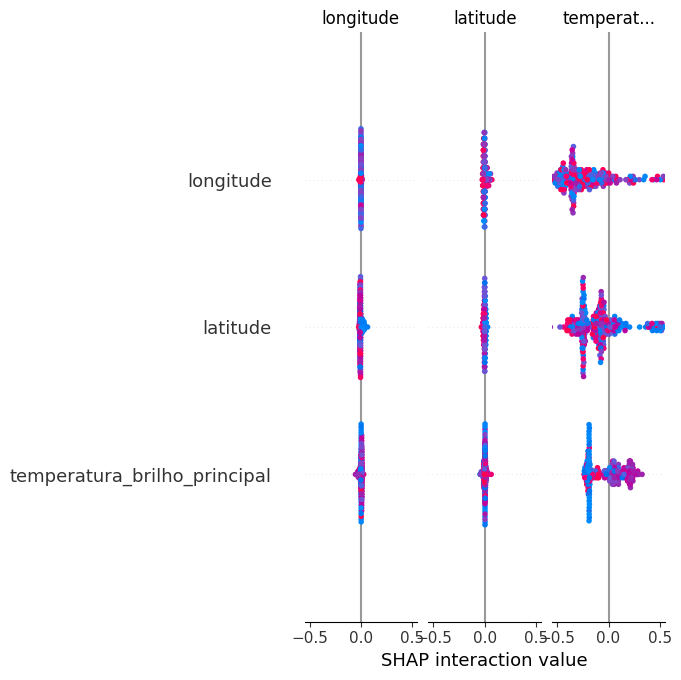

In [48]:
try:
    import shap

    modelo_shap = modelos["Random_Forest"]
    rf = modelo_shap.named_steps["model"]

    X_test_imp = modelo_shap.named_steps["imputer"].transform(X_test)
    X_test_imp = pd.DataFrame(X_test_imp, columns=features)

    amostra = X_test_imp.sample(
        min(300, len(X_test_imp)),
        random_state=42
    )

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(amostra)

    shap.summary_plot(
        shap_values,
        amostra,
        feature_names=features
    )

except Exception as erro:
    print("Não foi possível gerar o gráfico SHAP neste ambiente.")
    print(erro)

## Interpretação do SHAP

O SHAP foi usado para entender quais variáveis mais influenciaram a classificação de risco.

A análise é importante porque o objetivo do projeto não é apenas gerar uma previsão, mas também explicar o motivo da classificação. Em uma solução de monitoramento ambiental, isso ajuda a justificar por que um foco foi classificado como mais ou menos prioritário.

Na prática, variáveis como `frp`, `temperatura_brilho_principal` e `confianca_deteccao` tendem a ter maior impacto, pois foram diretamente ligadas à intensidade e confiabilidade do foco detectado.

## 13. Salvamento do modelo

In [49]:
joblib.dump(
    {
        "model": melhor_modelo,
        "features": features,
        "target": "risco",
        "classes": list(melhor_modelo.classes_)
    },
    "orbitalwatch_model.joblib"
)

print("Modelo salvo como orbitalwatch_model.joblib")

Modelo salvo como orbitalwatch_model.joblib


## 14. Conclusão

O modelo criado neste notebook classifica focos de calor já detectados por satélite em três níveis de risco.

Essa abordagem faz sentido para o OrbitalWatch porque ajuda a priorizar alertas. Em vez de apenas listar milhares de registros da NASA FIRMS, a plataforma pode destacar primeiro os focos com maior intensidade térmica, maior FRP e maior confiança de detecção.

Portanto, o notebook entrega uma camada simples de inteligência para apoiar o monitoramento ambiental proposto pelo projeto.

## Conclusão final

A solução não tenta prever incêndios futuros. O foco é classificar o risco de focos de calor que já foram detectados por satélite, ajudando a organizar a prioridade dos alertas.

Como limitação, a variável `risco` foi criada por uma regra técnica simples, e não por um órgão ambiental. Em uma versão futura, o modelo poderia ser melhorado com dados reais de área queimada, bioma, proximidade de áreas urbanas, clima, vento e histórico regional de queimadas.